**MEMBERS** 

Group: Cloud Analysts

Devika Raheja - 121187758 - draheja@umd.edu

Linda Tom - 117485752 - ltom@umd.edu

Prakruthi Kaganti Shivakumar - 121176028 - ksprak10@umd.edu

Rasika Pande - 121187499 - raspande@umd.edu

Shriya Goyal - 121280893 - sgoyal24@umd.edu

## IMPORTING LIBRARIES

In [1]:
import requests # type: ignore
import pandas as pd  # type: ignore
from time import sleep
import ast
from collections import Counter

/Users/shriya/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


# 1. Loading Bars in Philadelphia that Are Still Open

- Read the Yelp business JSON into a DataFrame

- Filtered for businesses whose categories include “Bars” and is_open == 1

- Ran value_counts() on the city column to see where open bars are located

- Further filtered to Philadelphia (philly DataFrame)

Inspected philly.info() and tallied missing values

In [2]:
business = pd.read_json('./yelp_academic_dataset_business.json', lines=True)
business.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."


# Loading Cafes in the city of Philadelphia that are still open

In [3]:
business = business[business['categories'].str.contains('Bars', na=False)].reset_index(drop=True)
business = business[business['is_open'] == 1]
business['city'].value_counts()[:30]

city
Philadelphia        1015
New Orleans          657
Nashville            644
Tampa                640
Indianapolis         480
Tucson               444
Edmonton             340
Reno                 338
Saint Louis          334
Boise                219
Santa Barbara        179
Clearwater           137
St. Louis            126
Saint Petersburg     122
St. Petersburg       111
Metairie             110
Wilmington            98
Franklin              85
Sparks                67
Meridian              64
Largo                 58
Brandon               57
Carmel                53
Dunedin               52
West Chester          48
New Port Richey       45
Fishers               44
Palm Harbor           42
Lutz                  39
St Louis              37
Name: count, dtype: int64

In [4]:
philly = business[business['city'] == 'Philadelphia'].reset_index().copy()
philly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   index         1015 non-null   int64  
 1   business_id   1015 non-null   object 
 2   name          1015 non-null   object 
 3   address       1015 non-null   object 
 4   city          1015 non-null   object 
 5   state         1015 non-null   object 
 6   postal_code   1015 non-null   object 
 7   latitude      1015 non-null   float64
 8   longitude     1015 non-null   float64
 9   stars         1015 non-null   float64
 10  review_count  1015 non-null   int64  
 11  is_open       1015 non-null   int64  
 12  attributes    1010 non-null   object 
 13  categories    1015 non-null   object 
 14  hours         923 non-null    object 
dtypes: float64(3), int64(3), object(9)
memory usage: 119.1+ KB


In [5]:
print(philly.isna().sum())

index            0
business_id      0
name             0
address          0
city             0
state            0
postal_code      0
latitude         0
longitude        0
stars            0
review_count     0
is_open          0
attributes       5
categories       0
hours           92
dtype: int64


# 2. Extracting and Counting Attribute Keys

- Converted any stringified dictionaries in philly['attributes'] back into Python dicts

- Collected all keys from the attributes dictionaries

- Counted how often each attribute appears across all bars

In [6]:
# Ensure that everything is a dictionary (safely parse any strings)
philly['attributes'] = philly['attributes'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Get all keys from the attributes dictionaries
attributes_keys = philly['attributes'].dropna().apply(lambda x: list(x.keys()) if isinstance(x, dict) else [])

# Flatten the list and check for frequency
all_key_list = Counter([key for keys in attributes_keys for key in keys])

# Show keys by frequency
print("Attribute keys present in new orleans dataset:")
for key_value, frequency in all_key_list.most_common():
    print(f"{key_value}: {frequency}")

Attribute keys present in new orleans dataset:
BusinessAcceptsCreditCards: 931
BusinessParking: 929
OutdoorSeating: 878
HasTV: 874
Ambience: 861
RestaurantsPriceRange2: 844
Alcohol: 835
RestaurantsReservations: 824
BikeParking: 807
RestaurantsTakeOut: 804
RestaurantsGoodForGroups: 796
RestaurantsDelivery: 794
WiFi: 783
NoiseLevel: 734
GoodForKids: 630
Caters: 629
RestaurantsAttire: 579
Music: 574
GoodForMeal: 566
HappyHour: 562
BestNights: 458
RestaurantsTableService: 444
WheelchairAccessible: 419
GoodForDancing: 338
CoatCheck: 338
DogsAllowed: 332
Smoking: 317
BusinessAcceptsBitcoin: 226
BYOB: 178
Corkage: 159
ByAppointmentOnly: 147
BYOBCorkage: 98
DriveThru: 61
AgesAllowed: 14
AcceptsInsurance: 3
Open24Hours: 2


In [9]:
# Helper to properly extract key
def get_attribute(value, key):
    return value.get(key) if isinstance(value, dict) else None

# Parse 'attributes' column if required
philly['attributes'] = philly['attributes'].apply(lambda value: ast.literal_eval(value) if isinstance(value, str) else value)

# Extract the relevant attributes
philly['accepts_cards']        = philly['attributes'].apply(lambda value: get_attribute(value, 'BusinessAcceptsCreditCards'))
philly['take_out']             = philly['attributes'].apply(lambda value: get_attribute(value, 'RestaurantsTakeOut'))
philly['delivery']             = philly['attributes'].apply(lambda value: get_attribute(value, 'RestaurantsDelivery'))
philly['outdoor_seating']      = philly['attributes'].apply(lambda value: get_attribute(value, 'OutdoorSeating'))
philly['price_range']          = philly['attributes'].apply(lambda value: get_attribute(value, 'RestaurantsPriceRange2'))
philly['reservations']         = philly['attributes'].apply(lambda value: get_attribute(value, 'RestaurantsReservations'))
philly['has_tv']               = philly['attributes'].apply(lambda value: get_attribute(value, 'HasTV'))
philly['ambience']             = philly['attributes'].apply(lambda value: get_attribute(value, 'Ambience'))
philly['good_for_groups']      = philly['attributes'].apply(lambda value: get_attribute(value, 'RestaurantsGoodForGroups'))
philly['alcohol']              = philly['attributes'].apply(lambda value: get_attribute(value, 'Alcohol'))
philly['good_for_kids']        = philly['attributes'].apply(lambda value: get_attribute(value, 'GoodForKids'))
philly['wifi']                 = philly['attributes'].apply(lambda value: get_attribute(value, 'WiFi'))
philly['attire']               = philly['attributes'].apply(lambda value: get_attribute(value, 'RestaurantsAttire'))
philly['noise_level']          = philly['attributes'].apply(lambda value: get_attribute(value, 'NoiseLevel'))
philly['bike_parking']         = philly['attributes'].apply(lambda value: get_attribute(value, 'BikeParking'))
philly['caters']               = philly['attributes'].apply(lambda value: get_attribute(value, 'Caters'))
philly['good_for_meal']        = philly['attributes'].apply(lambda value: get_attribute(value, 'GoodForMeal'))
philly['table_service']        = philly['attributes'].apply(lambda value: get_attribute(value, 'RestaurantsTableService'))
philly['happy_hour']           = philly['attributes'].apply(lambda value: get_attribute(value, 'HappyHour'))

# Get parking flag
def obtain_parking_flag(value):
    attribute = get_attribute(value, 'BusinessParking')
    try:
        parsed = ast.literal_eval(attribute) if isinstance(attribute, str) else attribute
        return any(parsed.values()) if isinstance(parsed, dict) else None
    except:
        return None

philly['has_parking'] = philly['attributes'].apply(obtain_parking_flag)
philly

,index,business_id,name,address,city,state,postal_code,latitude,longitude,stars,...,good_for_kids,wifi,attire,noise_level,bike_parking,caters,good_for_meal,table_service,happy_hour,has_parking
0,1,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,...,False,'free','casual',u'average',None,None,"{'dessert': True, 'latenight': None, 'lunch': ...",True,True,True
1,52,eJ77e9lGxY3ArzaoDbHhYw,Paddy Whacks Irish Sports Pub - South Street,150 South St,Philadelphia,PA,19147,39.941054,-75.145463,2.5,...,None,u'free',None,u'loud',True,None,None,None,None,True
2,53,7mpYTDb24SywNMRn3yeakQ,The Twisted Tail,509 S 2nd St,Philadelphia,PA,19147,39.941877,-75.145199,4.0,...,False,u'free',u'casual',u'average',False,True,"{'dessert': None, 'latenight': True, 'lunch': ...",True,True,True
3,87,MYoRNLb5chwjQe3c_k37Gg,Sean Thorntons Public House,2401 E Allegheny Ave,Philadelphia,PA,19134,39.988107,-75.105553,3.5,...,False,u'no','casual',None,None,None,None,None,None,True
4,111,BxR5hjyBnJZrm_nnaCtGQw,The Lunar Inn,3124 Richmond St,Philadelphia,PA,19134,39.982293,-75.103160,4.5,...,None,u'free',None,None,True,False,None,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1010,14271,ZGH8MzJa7Q7iIpmtzBAJAQ,Manayunk Brewery,4120 Main St,Philadelphia,PA,19127,40.022471,-75.218800,3.5,...,True,u'free',u'casual',u'average',True,True,"{'dessert': False, 'latenight': False, 'lunch'...",None,True,True
1011,14284,PWlShgXsJ8Yj3ucD7n8kdA,The Ranstead Room,2013 Ranstead St,Philadelphia,PA,19103,39.952654,-75.173931,4.0,...,None,u'no',u'dressy',u'average',False,None,None,None,True,True
1012,14297,eLi0bpsDoWQkBhJX1d46tg,Fergie's Pub,1214 Sansom St,Philadelphia,PA,19107,39.949596,-75.161128,3.5,...,False,u'no','casual',u'loud',True,False,"{'dessert': False, 'latenight': True, 'lunch':...",True,True,True
1013,14302,bKaBjDbtwQh_T-3ZpKJxRQ,Mr Sushi,7324 Oxford Ave,Philadelphia,PA,19111,40.062374,-75.083677,4.0,...,True,u'no',u'casual',u'average',True,True,"{'dessert': False, 'latenight': False, 'lunch'...",None,None,True


# 3. Loading the GEOID for Each Bar

- Iterated through philly’s latitude/longitude and queried the U.S. Census Geocoder API for each point

- Collected the returned census tract GEOID in allGEOID

- Added allGEOID as a new column GEO_ID in philly

In [7]:
import time

allGEOID = []
for index, row in philly.iterrows():
    if index % 100 == 0:
        print(f"Processing row {index}")
    url = "https://geocoding.geo.census.gov/geocoder/geographies/coordinates"
    params = {
        "x": row["longitude"], 
        "y": row["latitude"],
        "benchmark": 4,
        "vintage": "Current_Current",
        "format": "json"
    }
    res = requests.get(url, params).json()
    try:
        GEOID = res['result']['geographies']['2020 Census Blocks'][0]['GEOID']
        allGEOID.append(GEOID)
    except (KeyError, IndexError):
        allGEOID.append(None)  # If no GEOID found, append None

# Add GEOID column to DataFrame
philly["GEO_ID"] = allGEOID

Processing row 0
Processing row 100
Processing row 200
Processing row 300
Processing row 400
Processing row 500
Processing row 600
Processing row 700
Processing row 800
Processing row 900
Processing row 1000


# 4. Loading Reviews for All Philadelphia Bars

- Extracted the list of 1,015 business_ids from philly

- Read the Yelp review JSON in 500 K-row chunks, filtering each chunk to only those IDs

- Concatenated filtered chunks into reviews_df_raw

- Grouped by business_id and aggregated all review fields into lists, yielding reviews_df

In [13]:
business_id = []
business_id = philly['business_id']
business_id = list(business_id)
len(business_id)

1015

In [ ]:
filtered_chunks = []
file_path = './yelp_academic_dataset_review.json'
chunksize = 500000
chunk_iterator = pd.read_json(file_path, lines=True, chunksize=chunksize)

for i, chunk in enumerate(chunk_iterator):
    filtered = chunk[chunk['business_id'].isin(business_id)]
    
    if not filtered.empty:
        filtered_chunks.append(filtered)
        print(f"filtered_chunk_{i} with {len(filtered)} rows")


filtered_chunk_0 with 1015 rows


In [15]:
reviews_df_raw = pd.concat(filtered_chunks, ignore_index=True)
reviews_df = reviews_df_raw.groupby('business_id').agg(list).reset_index()
reviews_df.to_csv("filtered_reviews_grouped_full.csv", index=False)
reviews_df

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,-0TffRSXXIlBYVbb5AwfTg,[IndeBlue Modern Indian Food & Spirits],[205 South 13th St],[Philadelphia],[PA],[19107],[39.9485078263],[-75.1619688173],[4.5],[1097],[1],"[{'RestaurantsReservations': 'True', 'NoiseLev...","[Cocktail Bars, Food Delivery Services, Nightl...","[{'Monday': '0:0-0:0', 'Tuesday': '16:0-22:0',..."
1,-5Rah4ZvWsDu4oilUZxhtw,[World Cafe Live],[3025 Walnut St],[Philadelphia],[PA],[19104],[39.9520744759],[-75.1851766256],[4.0],[350],[1],"[{'RestaurantsGoodForGroups': 'True', 'Restaur...","[Nightlife, Arts & Entertainment, Restaurants,...","[{'Monday': '0:0-0:0', 'Tuesday': '10:0-22:0',..."
2,-ATiAtTikuGuqvaW2O6tNA,[Marathon],[121 S 16th St],[Philadelphia],[PA],[19102],[39.9504833638],[-75.1673305865],[3.5],[593],[1],"[{'RestaurantsAttire': ''casual'', 'Alcohol': ...","[Sandwiches, American (New), Lounges, Nightlif...","[{'Monday': '11:0-21:0', 'Tuesday': '11:0-21:0..."
3,-HewctWQ0P3HqKCr76bU-g,[Dawson Street Pub],[100 Dawson St],[Philadelphia],[PA],[19127],[40.018561],[-75.2127855],[4.0],[76],[1],"[{'OutdoorSeating': 'True', 'BusinessAcceptsCr...","[Nightlife, Pubs, Bars, Gastropubs, Restaurants]","[{'Monday': '12:0-2:0', 'Tuesday': '12:0-2:0',..."
4,-IZpkWsJKfq35eJLzaUcvA,[U Bar],[1220 Locust St],[Philadelphia],[PA],[19107],[39.947654],[-75.161553],[3.5],[58],[1],"[{'RestaurantsPriceRange2': '2', 'HasTV': 'Tru...","[Gay Bars, Bars, Nightlife]","[{'Monday': '11:0-2:0', 'Tuesday': '11:0-2:0',..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1010,zqZx70_E5Y_W4rjhahpJag,[Tashia's Cocktails & Cuisine],[1641 W Hunting Park Ave],[Philadelphia],[PA],[19140],[40.0159472577],[-75.1543130726],[3.5],[28],[1],"[{'Music': '{'dj': False, 'background_music': ...","[Bars, Lounges, Dive Bars, Cocktail Bars, Nigh...","[{'Monday': '13:0-2:0', 'Tuesday': '13:0-2:0',..."
1011,zspnOaAN4jpseR3X7YtX5Q,[Brownies Pub],[46 S 2nd St],[Philadelphia],[PA],[19106],[39.9488403],[-75.1441287],[3.5],[51],[1],"[{'RestaurantsGoodForGroups': 'False', 'Outdoo...","[Pubs, Nightlife, Bars, Sports Bars]","[{'Monday': '11:0-2:0', 'Tuesday': '11:0-2:0',..."
1012,zssISv4ZdplRT_Zcw8drPQ,[Golf & Social],[1080 N Delaware Ave],[Philadelphia],[PA],[19125],[39.965831],[-75.1327524],[2.0],[110],[1],"[{'BusinessParking': '{'garage': False, 'stree...","[Restaurants, Sports Bars, Nightlife, Bars, Am...","[{'Monday': '17:0-1:0', 'Tuesday': '17:0-1:0',..."
1013,zucC7rHpXPYBu7aEqj0NUw,[Libertine Restauraunt],[261 S 13th St],[Philadelphia],[PA],[19107],[39.9468905],[-75.1623567],[4.0],[117],[1],"[{'RestaurantsGoodForGroups': 'True', 'Wheelch...","[Bars, Cocktail Bars, American (New), Food, Re...","[{'Tuesday': '4:0-22:0', 'Wednesday': '4:0-22:..."


In [16]:
reviews_df = reviews_df[[col for col in reviews_df.columns if col not in philly.columns or col == 'business_id']]
final_df = pd.merge(philly, reviews_df, on='business_id')
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 36 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   index            1015 non-null   int64  
 1   business_id      1015 non-null   object 
 2   name             1015 non-null   object 
 3   address          1015 non-null   object 
 4   city             1015 non-null   object 
 5   state            1015 non-null   object 
 6   postal_code      1015 non-null   object 
 7   latitude         1015 non-null   float64
 8   longitude        1015 non-null   float64
 9   stars            1015 non-null   float64
 10  review_count     1015 non-null   int64  
 11  is_open          1015 non-null   int64  
 12  attributes       1010 non-null   object 
 13  categories       1015 non-null   object 
 14  hours            923 non-null    object 
 15  accepts_cards    931 non-null    object 
 16  take_out         804 non-null    object 
 17  delivery      

In [17]:
final_df

,index,business_id,name,address,city,state,postal_code,latitude,longitude,stars,...,wifi,attire,noise_level,bike_parking,caters,good_for_meal,table_service,happy_hour,has_parking,GEO_ID
0,1,MUTTqe8uqyMdBl186RmNeA,Tuna Bar,205 Race St,Philadelphia,PA,19106,39.953949,-75.143226,4.0,...,'free','casual',u'average',None,None,"{'dessert': True, 'latenight': None, 'lunch': ...",True,True,True,421010001023002
1,52,eJ77e9lGxY3ArzaoDbHhYw,Paddy Whacks Irish Sports Pub - South Street,150 South St,Philadelphia,PA,19147,39.941054,-75.145463,2.5,...,u'free',None,u'loud',True,None,None,None,None,True,421010016002001
2,53,7mpYTDb24SywNMRn3yeakQ,The Twisted Tail,509 S 2nd St,Philadelphia,PA,19147,39.941877,-75.145199,4.0,...,u'free',u'casual',u'average',False,True,"{'dessert': None, 'latenight': True, 'lunch': ...",True,True,True,421010010024016
3,87,MYoRNLb5chwjQe3c_k37Gg,Sean Thorntons Public House,2401 E Allegheny Ave,Philadelphia,PA,19134,39.988107,-75.105553,3.5,...,u'no','casual',None,None,None,None,None,None,True,421010382002012
4,111,BxR5hjyBnJZrm_nnaCtGQw,The Lunar Inn,3124 Richmond St,Philadelphia,PA,19134,39.982293,-75.103160,4.5,...,u'free',None,None,True,False,None,True,True,True,421010180022005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1010,14271,ZGH8MzJa7Q7iIpmtzBAJAQ,Manayunk Brewery,4120 Main St,Philadelphia,PA,19127,40.022471,-75.218800,3.5,...,u'free',u'casual',u'average',True,True,"{'dessert': False, 'latenight': False, 'lunch'...",None,True,True,421010210004022
1011,14284,PWlShgXsJ8Yj3ucD7n8kdA,The Ranstead Room,2013 Ranstead St,Philadelphia,PA,19103,39.952654,-75.173931,4.0,...,u'no',u'dressy',u'average',False,None,None,None,True,True,421010004012002
1012,14297,eLi0bpsDoWQkBhJX1d46tg,Fergie's Pub,1214 Sansom St,Philadelphia,PA,19107,39.949596,-75.161128,3.5,...,u'no','casual',u'loud',True,False,"{'dessert': False, 'latenight': True, 'lunch':...",True,True,True,421010006001011
1013,14302,bKaBjDbtwQh_T-3ZpKJxRQ,Mr Sushi,7324 Oxford Ave,Philadelphia,PA,19111,40.062374,-75.083677,4.0,...,u'no',u'casual',u'average',True,True,"{'dessert': False, 'latenight': False, 'lunch'...",None,None,True,421010338002013


### Sanity Check

The final_df should have 1015 rows and 36 cols (22 cols from business (philly) and 14 cols from reviews)

In [ ]:
final_df.shape

# 5. Loading Demographics for Each GEOID

<h4> 5.1 Read & Filter Demographics </h4>

- Read demographic.csv into demographics

- Trimmed the GEO_ID field to its last 11 characters

- Filtered demographics to only those GEOIDs in allGEOID

In [19]:
demographics = pd.read_csv("demographic.csv")
demographics

/var/folders/2y/ypwr61vn22s2vwgt1bpv7mvr0000gn/T/ipykernel_26255/1651362558.py:1: DtypeWarning: Columns (2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,128,129,132,133,136,137,140,141,144,145,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,176,177,178,179,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,276,278,279,280,281,282,283,284,285,286,287,288,289,290,292,293,294,296,297,298,299,300,301,302,306,310,312,313,314,315,316,317,318,319,320,321,322,323,326,328,329,330,331,332,333,3

,GEO_ID,NAME,DP03_0001E,DP03_0001M,DP03_0002E,DP03_0002M,DP03_0003E,DP03_0003M,DP03_0004E,DP03_0004M,...,DP03_0133PM,DP03_0134PE,DP03_0134PM,DP03_0135PE,DP03_0135PM,DP03_0136PE,DP03_0136PM,DP03_0137PE,DP03_0137PM,Unnamed: 550
0,Geography,Geographic Area Name,Estimate!!EMPLOYMENT STATUS!!Population 16 yea...,Margin of Error!!EMPLOYMENT STATUS!!Population...,Estimate!!EMPLOYMENT STATUS!!Population 16 yea...,Margin of Error!!EMPLOYMENT STATUS!!Population...,Estimate!!EMPLOYMENT STATUS!!Population 16 yea...,Margin of Error!!EMPLOYMENT STATUS!!Population...,Estimate!!EMPLOYMENT STATUS!!Population 16 yea...,Margin of Error!!EMPLOYMENT STATUS!!Population...,...,Percent Margin of Error!!PERCENTAGE OF FAMILIE...,Percent!!PERCENTAGE OF FAMILIES AND PEOPLE WHO...,Percent Margin of Error!!PERCENTAGE OF FAMILIE...,Percent!!PERCENTAGE OF FAMILIES AND PEOPLE WHO...,Percent Margin of Error!!PERCENTAGE OF FAMILIE...,Percent!!PERCENTAGE OF FAMILIES AND PEOPLE WHO...,Percent Margin of Error!!PERCENTAGE OF FAMILIE...,Percent!!PERCENTAGE OF FAMILIES AND PEOPLE WHO...,Percent Margin of Error!!PERCENTAGE OF FAMILIE...,NaN
1,1400000US42001030101,Census Tract 301.01; Adams County; Pennsylvania,2213,73,1451,116,1450,116,1400,120,...,2.7,6.6,3.5,2.9,3.5,4.1,3.5,12.6,8.3,NaN
2,1400000US42001030103,Census Tract 301.03; Adams County; Pennsylvania,2012,312,1457,336,1451,336,1443,338,...,2.3,3.4,2.8,2.6,4.5,2.8,3.7,13.2,15.2,NaN
3,1400000US42001030104,Census Tract 301.04; Adams County; Pennsylvania,2861,269,1831,248,1831,248,1749,239,...,2.2,3.8,3.2,0.0,3.4,3.5,5.5,8.4,7.8,NaN
4,1400000US42001030200,Census Tract 302; Adams County; Pennsylvania,4291,329,2847,283,2823,277,2761,273,...,3.5,8.0,4.4,7.1,4.2,7.5,6.0,19.8,7.4,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3442,1400000US42133023902,Census Tract 239.02; York County; Pennsylvania,2297,229,1615,142,1608,140,1546,136,...,3.0,3.5,3.0,4.8,6.7,2.2,2.1,14.4,14.2,NaN
3443,1400000US42133023903,Census Tract 239.03; York County; Pennsylvania,2310,235,1485,166,1479,164,1419,163,...,3.7,6.4,4.3,9.4,4.6,5.2,3.9,23.9,10.7,NaN
3444,1400000US42133023904,Census Tract 239.04; York County; Pennsylvania,3721,383,2596,567,2567,579,2502,585,...,0.8,0.5,0.1,2.4,3.7,0.5,0.8,2.4,1.0,NaN
3445,1400000US42133024001,Census Tract 240.01; York County; Pennsylvania,4579,274,2966,313,2960,313,2679,347,...,3.8,6.2,4.5,6.2,4.9,1.7,1.8,28.9,14.5,NaN


In [20]:
demographics['GEO_ID']= demographics['GEO_ID'].str[-11:]
allgeoid_11 = [geoid[:11]for geoid in allGEOID]
demographics = demographics[demographics['GEO_ID'].isin(allgeoid_11)]
demographics

,GEO_ID,NAME,DP03_0001E,DP03_0001M,DP03_0002E,DP03_0002M,DP03_0003E,DP03_0003M,DP03_0004E,DP03_0004M,...,DP03_0133PM,DP03_0134PE,DP03_0134PM,DP03_0135PE,DP03_0135PM,DP03_0136PE,DP03_0136PM,DP03_0137PE,DP03_0137PM,Unnamed: 550
1338,42045403701,Census Tract 4037.01; Delaware County; Pennsyl...,1502,182,985,175,985,175,817,158,...,9.8,17.7,10.9,20.4,15.6,22.5,14.0,25.2,17.5,NaN
1438,42045980000,Census Tract 9800; Delaware County; Pennsylvania,0,11,0,11,0,11,0,11,...,**,-,**,-,**,-,**,-,**,NaN
2302,42091202500,Census Tract 2025; Montgomery County; Pennsylv...,5151,707,3574,720,3574,720,3354,640,...,6.9,20.9,9.4,0.6,0.9,3.3,3.9,37.5,18.0,NaN
2559,42101000101,Census Tract 1.01; Philadelphia County; Pennsy...,1980,329,1773,350,1773,350,1701,332,...,1.9,1.8,2.2,0.0,12.3,0.0,5.0,2.3,2.7,NaN
2560,42101000102,Census Tract 1.02; Philadelphia County; Pennsy...,2816,438,2512,430,2492,426,2411,428,...,3.4,5.2,3.1,17.2,17.4,0.0,3.0,8.7,4.4,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2954,42101980600,Census Tract 9806; Philadelphia County; Pennsy...,0,11,0,11,0,11,0,11,...,**,-,**,-,**,-,**,-,**,NaN
2955,42101980701,Census Tract 9807.01; Philadelphia County; Pen...,0,11,0,11,0,11,0,11,...,**,-,**,-,**,-,**,-,**,NaN
2956,42101980702,Census Tract 9807.02; Philadelphia County; Pen...,0,11,0,11,0,11,0,11,...,**,-,**,-,**,-,**,-,**,NaN
2958,42101980901,Census Tract 9809.01; Philadelphia County; Pen...,0,11,0,11,0,11,0,11,...,**,-,**,-,**,-,**,-,**,NaN


<h4> 5.2 Checking for Missing GEOIDs </h4>
It shows all present

In [22]:
missing_geoids = [g for g in allGEOID if g not in set(demographics['GEO_ID'])]
print(len(missing_geoids))
print(missing_geoids)
print(len(allGEOID))

1015
['421010001023002', '421010016002001', '421010010024016', '421010382002012', '421010180022005', '421010307001002', '421010078005001', '421010012031007', '421010016001009', '421010009011005', '421010012031009', '421010001014008', '421010331012018', '421010007013003', '421010007021000', '421019809012002', '421010008052003', '421010144004007', '421010001014001', '421010004041004', '421010078005000', '421010381001035', '421010142012018', '421010001014012', '421010316003001', '421010088023002', '421010352003019', '421010016001003', '421010010024003', '421010291001008', '421010210004024', '421010039011014', '421010207012011', '421010133001013', '421010373004006', '421010376001000', '421010001014014', '421010158003012', '421010210004004', '421010216002003', '421010004043002', '421010376002020', '421010001014008', '421010348032000', '421010147002019', '421010028022001', '421010369024004', '421010369026013', '421010335001009', '421010379003012', '420454037012029', '421010001012004', '42101

# 6. Selecting Demographic Features

- From the full census file, extracted these columns:

DP03_0001E → employment status

DP03_0026E → occupation

DP03_0032E → industry

DP03_0046E → worker class

DP03_0051E → income (with benefits)

- Renamed them to: ['GEOID','employment status','occupation','industry','worker_class','income_benefits']

In [219]:
demographics_df = demographics[["GEO_ID", 'DP03_0001E', 'DP03_0026E', 'DP03_0032E', 'DP03_0046E', 'DP03_0051E']]
demographics_df.columns = ['GEOID', 'employment status', 'occupation', 'industry', 'worker_class', 'income_benefits']

demographics_df

,GEOID,employment status,occupation,industry,worker_class,income_benefits
1338,42045403701,1502,817,817,817,742
1438,42045980000,0,0,0,0,0
2302,42091202500,5151,3354,3354,3354,2510
2559,42101000101,1980,1701,1701,1701,1492
2560,42101000102,2816,2411,2411,2411,2033
...,...,...,...,...,...,...
2954,42101980600,0,0,0,0,0
2955,42101980701,0,0,0,0,0
2956,42101980702,0,0,0,0,0
2958,42101980901,0,0,0,0,0


# 7. Merging into final_df

- Trimmed reviews_df to only the business_id column plus aggregated review fields

- Merged philly (which now has GEO_ID) with reviews_df on business_id

In [221]:
# Already gives count of businesses per GEO_ID
business_count = final_df.groupby('GEO_ID')['business_id'].nunique().reset_index(name='num_businesses')

# Sort by number of businesses descending
business_count_sorted = business_count.sort_values(by='num_businesses', ascending=False)

# Display as scrollable styled table
#display(business_count_sorted.style.set_sticky())

In [223]:
demo = pd.read_csv('./demo.csv')
demo['GEO_ID'] = demo['GEO_ID'].str.split('US').str[-1]
allGEOID_10 = [geoid[:11] for geoid in allGEOID]
demo = demo[demo['GEO_ID'].isin(allGEOID_10)]
demo

/var/folders/2y/ypwr61vn22s2vwgt1bpv7mvr0000gn/T/ipykernel_26255/4287513196.py:1: DtypeWarning: Columns (2,3,4,5,6,7,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,58,59,60,61,62,63,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,238,246,254,324,338,372) have mixed types. Specify dtype option on import or set low_memory=False.
  demo = pd.read_csv('./demo.csv')


,GEO_ID,NAME,DP05_0001E,DP05_0001M,DP05_0002E,DP05_0002M,DP05_0003E,DP05_0003M,DP05_0004E,DP05_0004M,...,DP05_0090PM,DP05_0091PE,DP05_0091PM,DP05_0092PE,DP05_0092PM,DP05_0093PE,DP05_0093PM,DP05_0094PE,DP05_0094PM,Unnamed: 378
1338,42045403701,Census Tract 4037.01; Delaware County; Pennsyl...,1731,212,958,158,773,120,123.9,26.2,...,1.6,(X),(X),1434,(X),56.6,6.2,43.4,6.2,NaN
1438,42045980000,Census Tract 9800; Delaware County; Pennsylvania,0,11,0,11,0,11,-,**,...,**,(X),(X),0,(X),-,**,-,**,NaN
2302,42091202500,Census Tract 2025; Montgomery County; Pennsylv...,5826,875,2546,597,3280,453,77.6,17.2,...,3.4,(X),(X),4531,(X),43.4,5.9,56.6,5.9,NaN
2559,42101000101,Census Tract 1.01; Philadelphia County; Pennsy...,1996,329,690,202,1306,238,52.8,17.4,...,2.8,(X),(X),1830,(X),35.3,7.4,64.7,7.4,NaN
2560,42101000102,Census Tract 1.02; Philadelphia County; Pennsy...,3025,492,1764,426,1261,259,139.9,45.1,...,1.2,(X),(X),2662,(X),56.4,8.1,43.6,8.1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2954,42101980600,Census Tract 9806; Philadelphia County; Pennsy...,0,11,0,11,0,11,-,**,...,**,(X),(X),0,(X),-,**,-,**,NaN
2955,42101980701,Census Tract 9807.01; Philadelphia County; Pen...,0,11,0,11,0,11,-,**,...,**,(X),(X),0,(X),-,**,-,**,NaN
2956,42101980702,Census Tract 9807.02; Philadelphia County; Pen...,0,11,0,11,0,11,-,**,...,**,(X),(X),0,(X),-,**,-,**,NaN
2958,42101980901,Census Tract 9809.01; Philadelphia County; Pen...,0,11,0,11,0,11,-,**,...,**,(X),(X),0,(X),-,**,-,**,NaN


In [229]:
demo_df = demo[['GEO_ID', 'DP05_0002E', 'DP05_0003E', 'DP05_0022E', 'DP05_0024E']]
demo_df.columns = ['GEOID', 'Males', 'Females', 'Above21', 'Above65' ]
final_demographics_df = pd.merge(demographics_df, demo_df, on = "GEOID")
final_demographics_df

,GEOID,employment status,occupation,industry,worker_class,income_benefits,Males,Females,Above21,Above65
0,42045403701,1502,817,817,817,742,958,773,1419,284
1,42045980000,0,0,0,0,0,0,0,0,0
2,42091202500,5151,3354,3354,3354,2510,2546,3280,4257,1080
3,42101000101,1980,1701,1701,1701,1492,690,1306,1980,229
4,42101000102,2816,2411,2411,2411,2033,1764,1261,2816,239
...,...,...,...,...,...,...,...,...,...,...
209,42101980600,0,0,0,0,0,0,0,0,0
210,42101980701,0,0,0,0,0,0,0,0,0
211,42101980702,0,0,0,0,0,0,0,0,0
212,42101980901,0,0,0,0,0,0,0,0,0


### Sanity Check

The final demographics merged dataset should have 214 rows and 10 cols (5 cols from demo.df and 5 cols from demographics.df)

In [ ]:
final_demographics_df.shape

(1015, 36)

final

# 8. Exploratory Data Analysis on final_df

#### 8.1 General Summary
 
- final_df.shape  
-  final_df.info() and  
-  final_df.describe()

In [32]:
final_df.shape

(1015, 36)

In [33]:
print(final_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 36 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   index            1015 non-null   int64  
 1   business_id      1015 non-null   object 
 2   name             1015 non-null   object 
 3   address          1015 non-null   object 
 4   city             1015 non-null   object 
 5   state            1015 non-null   object 
 6   postal_code      1015 non-null   object 
 7   latitude         1015 non-null   float64
 8   longitude        1015 non-null   float64
 9   stars            1015 non-null   float64
 10  review_count     1015 non-null   int64  
 11  is_open          1015 non-null   int64  
 12  attributes       1010 non-null   object 
 13  categories       1015 non-null   object 
 14  hours            923 non-null    object 
 15  accepts_cards    931 non-null    object 
 16  take_out         804 non-null    object 
 17  delivery      

Checking quick statistics for numerical columns

In [35]:
final_df.describe()

,index,latitude,longitude,stars,review_count,is_open
count,1015.000000,1015.000000,1015.000000,1015.000000,1015.000000,1015.0
mean,7323.647291,39.967589,-75.155835,3.701478,200.481773,1.0
std,4230.498920,0.046150,0.048801,0.680126,363.535737,0.0
min,1.000000,39.872730,-75.274794,1.000000,5.000000,1.0
25%,3554.500000,39.947606,-75.173741,3.500000,24.000000,1.0
50%,7292.000000,39.952783,-75.161549,4.000000,82.000000,1.0
75%,11025.500000,39.975037,-75.144399,4.000000,225.500000,1.0
max,14313.000000,40.132470,-74.960985,5.000000,5721.000000,1.0


Check for NULL values in all columns

In [37]:
print(final_df.isna().sum())

index                0
business_id          0
name                 0
address              0
city                 0
state                0
postal_code          0
latitude             0
longitude            0
stars                0
review_count         0
is_open              0
attributes           5
categories           0
hours               92
accepts_cards       84
take_out           211
delivery           221
outdoor_seating    137
price_range        171
reservations       191
has_tv             141
ambience           154
good_for_groups    219
alcohol            180
good_for_kids      385
wifi               232
attire             436
noise_level        281
bike_parking       208
caters             386
good_for_meal      449
table_service      571
happy_hour         453
has_parking         96
GEO_ID               0
dtype: int64


#### 8.2 SANITY CHECKING

We expect business_id to be unique, so any duplicates would indicate data issues that need resolution before merging or analysis

In [40]:
duplicate_businesses = final_df['business_id'].duplicated().sum()
print(f"Duplicate business_id entries: {duplicate_businesses}")

Duplicate business_id entries: 0


Whether the data is of Philadelphia only

In [42]:
final_df['city'].unique()

array(['Philadelphia'], dtype=object)

Check if any discrepancies with the reviews and stars column. Business has 0 reviews but a high star rating?

In [44]:
high_ratings_no_reviews = final_df[(final_df['review_count'] == 0) & (final_df['stars'] > 3)]
print("\nBars with no reviews but more than 3 reviews:", high_ratings_no_reviews.shape[0])


Bars with no reviews but more than 3 reviews: 0


Checking if postal codes are clean (it should be 5 digits only)

In [46]:
invalid_postal = final_df[~final_df['postal_code'].astype(str).str.match(r'\d{5}')]
print("\nNumber of invalid postal codes:", invalid_postal.shape[0])


Number of invalid postal codes: 0


As a sanity check, we're verifying whether the GEOID lengths are unusual. They should be 10 or 11 digits long

In [48]:
final_df['GEO_ID'] = final_df['GEO_ID'].astype(str)
print(final_df['GEO_ID'].str.len().value_counts())

GEO_ID
15    1015
Name: count, dtype: int64


Check if businesses with 'is_open' = 0 have any new reviews

In [50]:
closed_businesses = final_df[(final_df['is_open'] == 0)]
print("\nClosed businesses count:", closed_businesses.shape[0])


Closed businesses count: 0


In [51]:
final_df['price_range'].value_counts()

price_range
2       594
1       182
3        59
4         8
None      1
Name: count, dtype: int64

##### Distribution of Star Ratings

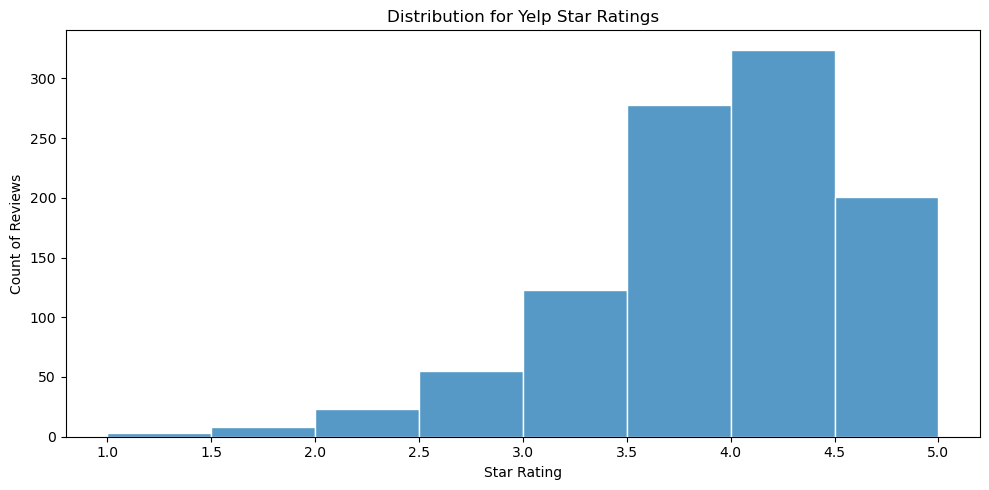

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(final_df['stars'], bins=[1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5], edgecolor='white')
plt.title('Distribution for Yelp Star Ratings')
plt.xlabel('Star Rating')
plt.ylabel('Count of Reviews')
plt.xticks([1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5])
plt.tight_layout()
plt.show()

##### Star Ratings by Restaurant Density Group

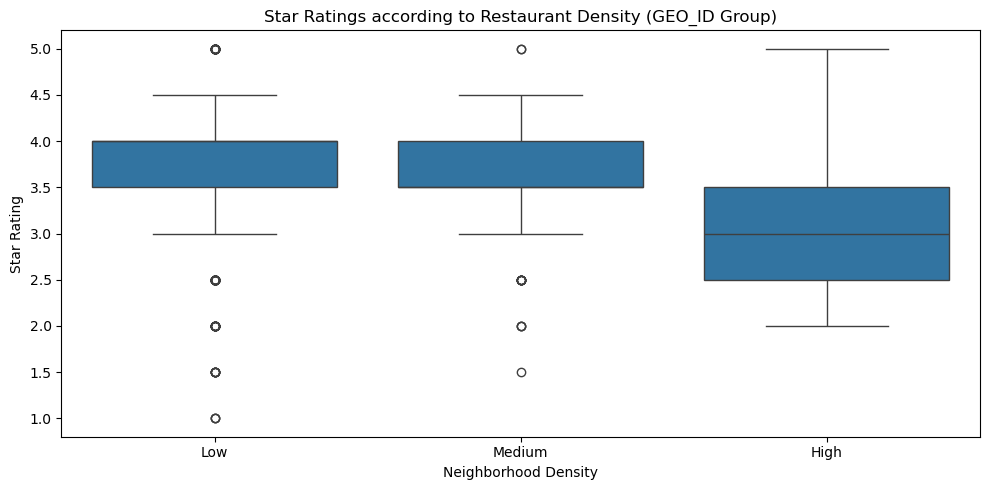

In [64]:
geo_counts = final_df.groupby('GEO_ID')['business_id'].count().reset_index(name='restaurant_count')

#  Merge into df
final_df = final_df.merge(geo_counts, on='GEO_ID', how='left')

# Adjust bin density
final_df['density_group'] = pd.cut(
    final_df['restaurant_count'],
    bins=[0, 3, 10, final_df['restaurant_count'].max()],
    labels=['Low', 'Medium', 'High']
)
# Show visualization
plt.figure(figsize=(10, 5))
sns.boxplot(data=final_df, x='density_group', y='stars', order=['Low', 'Medium', 'High'])
plt.title('Star Ratings according to Restaurant Density (GEO_ID Group)')
plt.xlabel('Neighborhood Density')
plt.ylabel('Star Rating')
plt.tight_layout()
plt.show()

Star ratings are relatively consistent across low, medium, and high-density neighborhoods, but slightly higher in high-density areas

##### Average Star Rating against Total Reviews for each GEOID

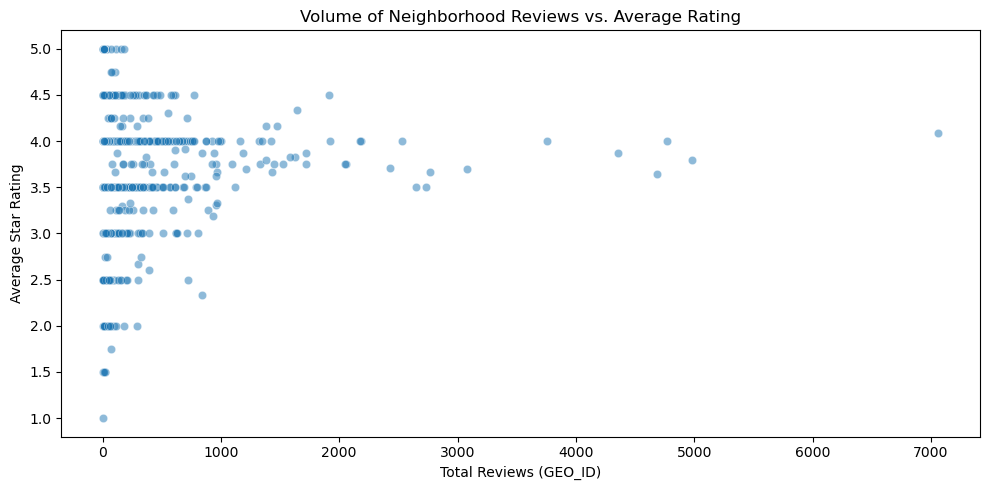

In [67]:
summary_value = final_df.groupby('GEO_ID').agg(
    avg_rating=('stars', 'mean'),
    total_reviews=('review_count', 'sum')
).reset_index()

plt.figure(figsize=(10, 5))
sns.scatterplot(data=summary_value, x='total_reviews', y='avg_rating', alpha=0.5)
plt.title('Volume of Neighborhood Reviews vs. Average Rating')
plt.xlabel('Total Reviews (GEO_ID)')
plt.ylabel('Average Star Rating')
plt.tight_layout()
plt.show()

Business count by price_range will help us understand affordability in different neighborhoods

price_range
2       594
1       182
3        59
4         8
None      1
Name: count, dtype: int64


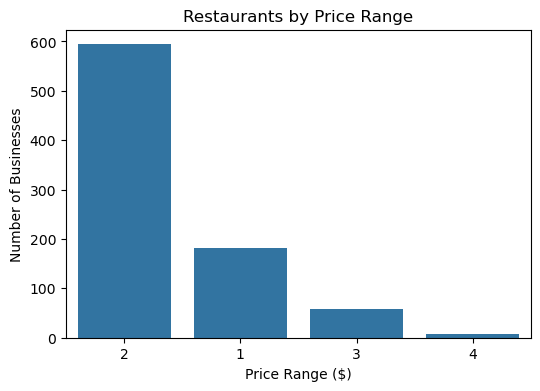

In [69]:
print(final_df['price_range'].value_counts())

# plt.figure(figsize=(6,4))
# sns.countplot(data=final_df, x='price_range')
# plt.title('Restaurants by Price Range')
# plt.xlabel('Price Range ($)')
# plt.ylabel('Number of Businesses')
# plt.show()

plt.figure(figsize=(6,4))
sns.countplot(data=final_df[(final_df['price_range'].notnull()) & (final_df['price_range'] != 'None')], x='price_range')
plt.title('Restaurants by Price Range')
plt.xlabel('Price Range ($)')
plt.ylabel('Number of Businesses')
plt.show()

##### Trying to dive into how well different pricing models perform to check if expensive places do better or worse in terms of ratings

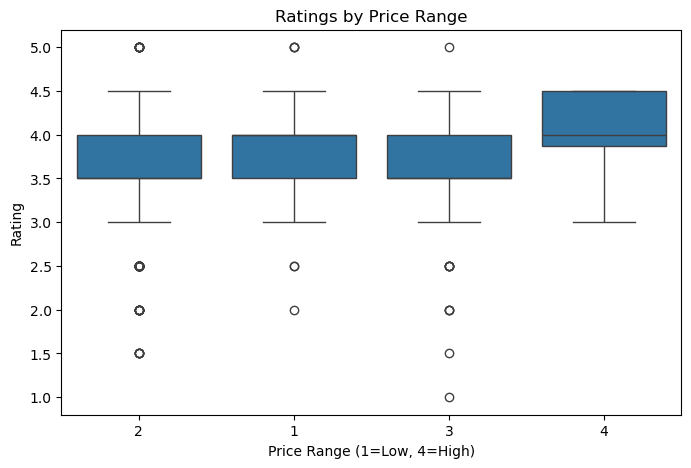

In [71]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='price_range', y='stars', data=final_df[(final_df['price_range'].notnull()) & (final_df['price_range'] != 'None')])
plt.title("Ratings by Price Range")
plt.xlabel("Price Range (1=Low, 4=High)")
plt.ylabel("Rating")
plt.show()

Most expensive (4) restaurants tend to get higher ratings

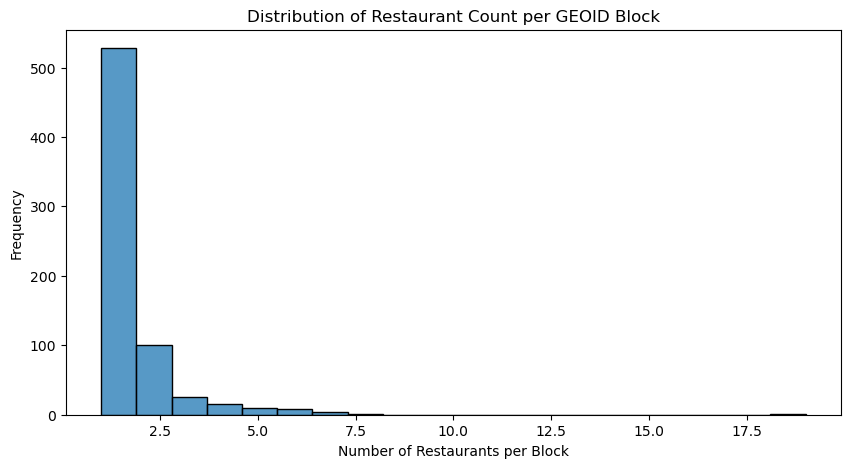

In [73]:
geoid_count = final_df['GEO_ID'].value_counts().reset_index()
geoid_count.columns = ['GEO_ID', 'restaurant_count']

plt.figure(figsize=(10,5))
sns.histplot(geoid_count['restaurant_count'], bins=20)
plt.title('Distribution of Restaurant Count per GEOID Block')
plt.xlabel('Number of Restaurants per Block')
plt.ylabel('Frequency')
plt.show()

Most `GEOID` blocks have only 1 to 10 restaurants. This shows many areas aren’t oversaturated, which is good news for opening new businesses in under-served locations

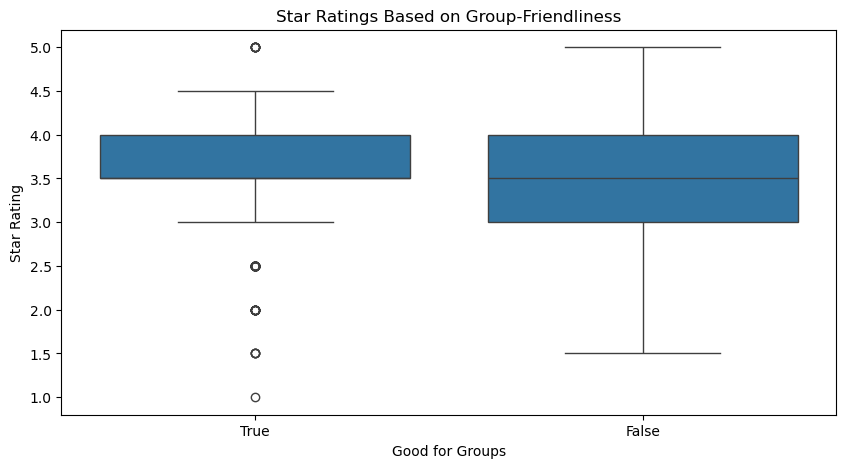

In [75]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=final_df[
        (final_df['good_for_groups'].notnull()) &
        (final_df['good_for_groups'] != 'None') &
        (final_df['good_for_groups'] != '') &
        (final_df['price_range'].notnull()) &
        (final_df['price_range'] != 'None')
    ],
    x='good_for_groups',
    y='stars'
)
plt.title("Star Ratings Based on Group-Friendliness")
plt.xlabel("Good for Groups")
plt.ylabel("Star Rating")
plt.show()

Group-friendliness might not be a strong differentiator in ratings

In [77]:
final_df['hours'].value_counts()

hours
{'Monday': '11:0-2:0', 'Tuesday': '11:0-2:0', 'Wednesday': '11:0-2:0', 'Thursday': '11:0-2:0', 'Friday': '11:0-2:0', 'Saturday': '11:0-2:0', 'Sunday': '11:0-2:0'}           45
{'Monday': '16:0-2:0', 'Tuesday': '16:0-2:0', 'Wednesday': '16:0-2:0', 'Thursday': '16:0-2:0', 'Friday': '16:0-2:0', 'Saturday': '16:0-2:0', 'Sunday': '16:0-2:0'}           12
{'Monday': '11:0-22:0', 'Tuesday': '11:0-22:0', 'Wednesday': '11:0-22:0', 'Thursday': '11:0-22:0', 'Friday': '11:0-22:0', 'Saturday': '11:0-22:0', 'Sunday': '11:0-22:0'}    11
{'Monday': '12:0-2:0', 'Tuesday': '12:0-2:0', 'Wednesday': '12:0-2:0', 'Thursday': '12:0-2:0', 'Friday': '12:0-2:0', 'Saturday': '12:0-2:0', 'Sunday': '12:0-2:0'}           11
{'Monday': '11:30-2:0', 'Tuesday': '11:30-2:0', 'Wednesday': '11:30-2:0', 'Thursday': '11:30-2:0', 'Friday': '11:30-2:0', 'Saturday': '11:30-2:0', 'Sunday': '11:30-2:0'}     9
                                                                                                                  

In [78]:
final_df[final_df['categories'].str.contains('bars', case=False, na=False)].shape[0]

1015

In [79]:
final_df['stars'].value_counts()

stars
4.0    324
3.5    278
4.5    169
3.0    123
2.5     55
5.0     32
2.0     23
1.5      8
1.0      3
Name: count, dtype: int64

open_after_11pm
False    3.754237
True     3.673222
Name: stars, dtype: float64


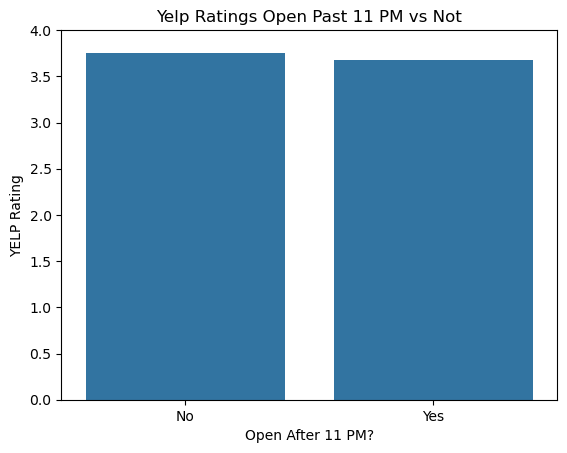

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def is_open_after_11pm(hours_dict):
    if not isinstance(hours_dict, dict):
        return False  
    for day, time_range in hours_dict.items():
        try:
            open_time, close_time = time_range.split('-')
            open_hour = int(open_time.split(':')[0])
            close_hour = int(close_time.split(':')[0])
            
        
            if close_hour >= 23 or close_hour <= 5:
                return True
        except Exception as e:
            pass 
    return False


final_df['open_after_11pm'] = final_df['hours'].apply(is_open_after_11pm)


mean_stars = final_df.groupby('open_after_11pm')['stars'].mean()
print(mean_stars)


sns.barplot(x=mean_stars.index, y=mean_stars.values)
plt.title('Yelp Ratings Open Past 11 PM vs Not')
plt.xlabel('Open After 11 PM?')
plt.ylabel('YELP Rating')
plt.xticks([0, 1], ['No', 'Yes'])
plt.ylim(0, 4) 
plt.show()

Bars are roughly similar regardless of late-night hours.Staying open past 11 PM does not strongly impact Yelp ratings.

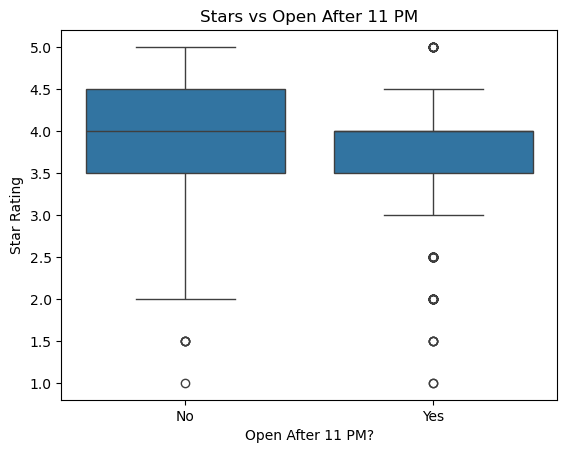

In [95]:
sns.boxplot(data=final_df, x='open_after_11pm', y='stars')
plt.title('Stars vs Open After 11 PM')
plt.xlabel('Open After 11 PM?')
plt.ylabel('Star Rating')
plt.xticks([0, 1], ['No', 'Yes'])
plt.show()

The boxplot shows that bars open past 11 PM and those that close earlier share nearly identical medians (around 4 stars) and heavily overlapping interquartile ranges, with similar variability and outlier patterns. In other words, staying open late neither boosts nor hurts Yelp ratings on average suggesting that factors like location, pricing, and ambience are more influential on customer satisfaction than closing time.

##### Bars with outdoor seating impact star rating

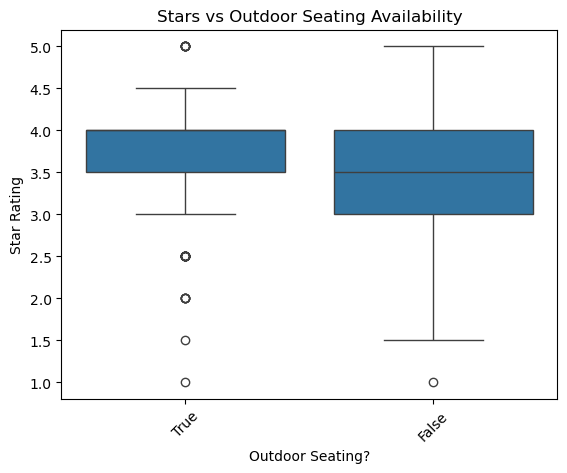

In [97]:
sns.boxplot(
    data=final_df[
        (final_df['outdoor_seating'].notnull()) &
        (final_df['outdoor_seating'] != 'None') &
        (final_df['outdoor_seating'] != '')
    ],
    x='outdoor_seating',
    y='stars'
)
plt.title('Stars vs Outdoor Seating Availability')
plt.xlabel('Outdoor Seating?')
plt.ylabel('Star Rating')
plt.xticks(rotation=45)
plt.show()

Checking which areas have the best quality bars overall? This will help business to understand whether invest in those areas! or improve bars in low-rating areas!

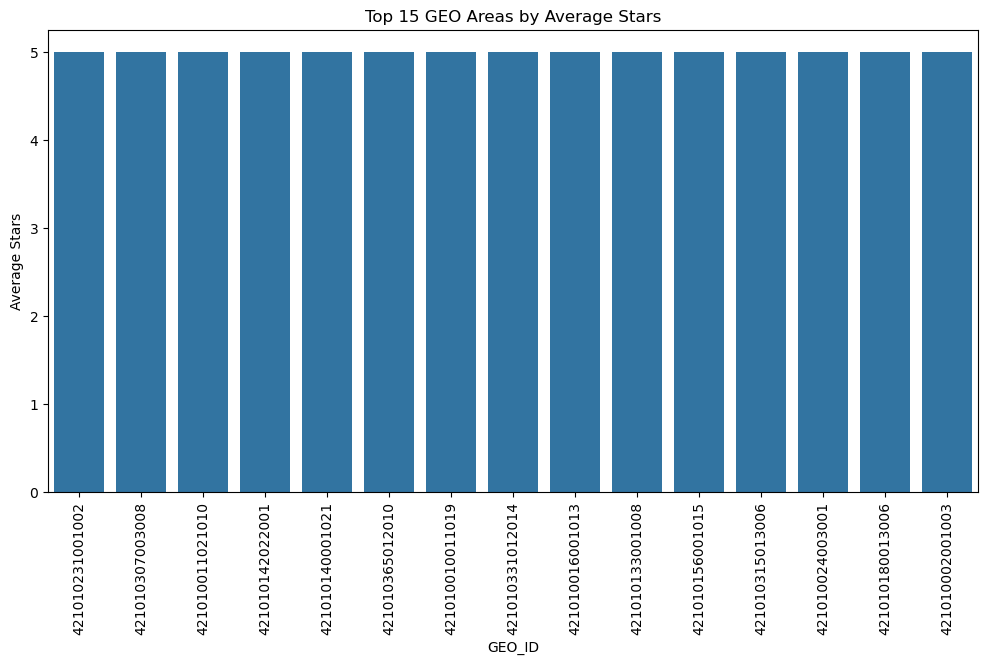

In [100]:
geo_avg = final_df.groupby('GEO_ID')['stars'].mean().reset_index().sort_values('stars', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(data=geo_avg.head(15), x='GEO_ID', y='stars')
plt.xticks(rotation=90)
plt.title('Top 15 GEO Areas by Average Stars')
plt.xlabel('GEO_ID')
plt.ylabel('Average Stars')
plt.show()

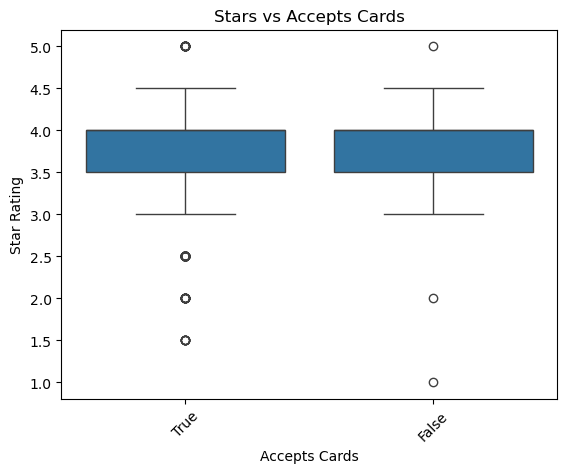

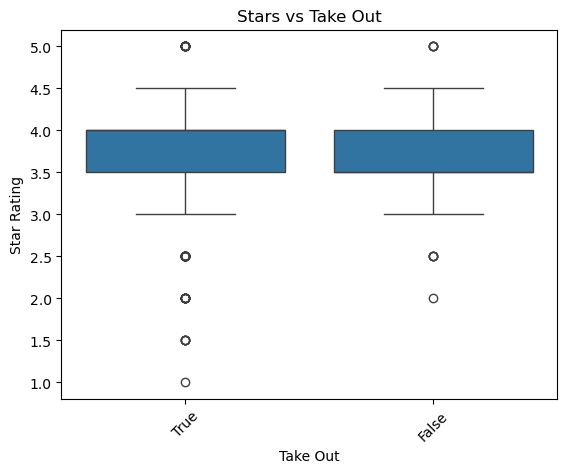

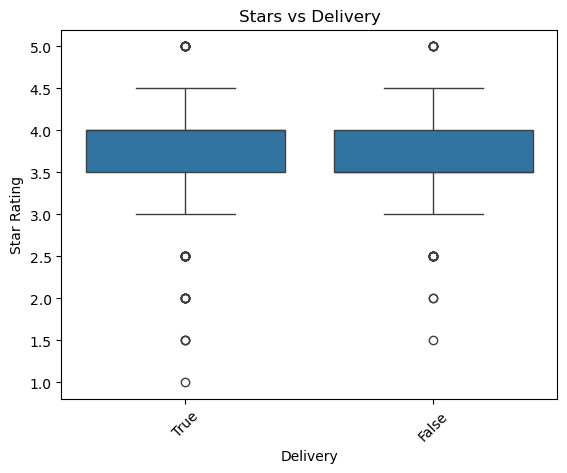

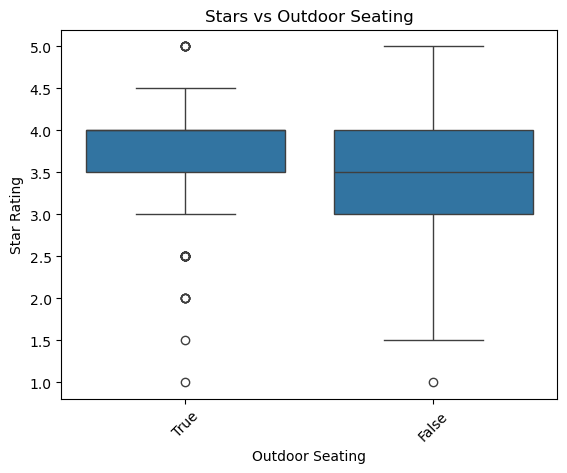

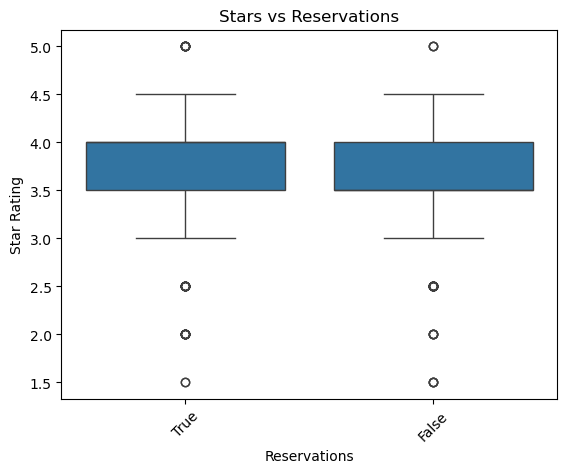

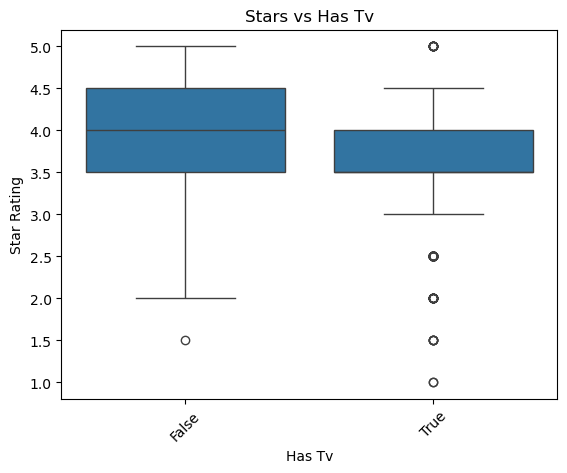

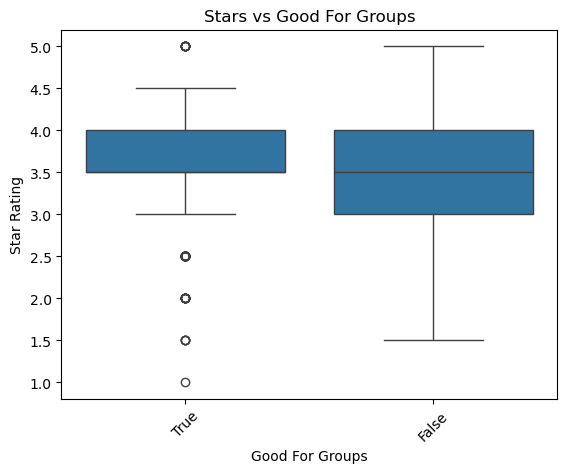

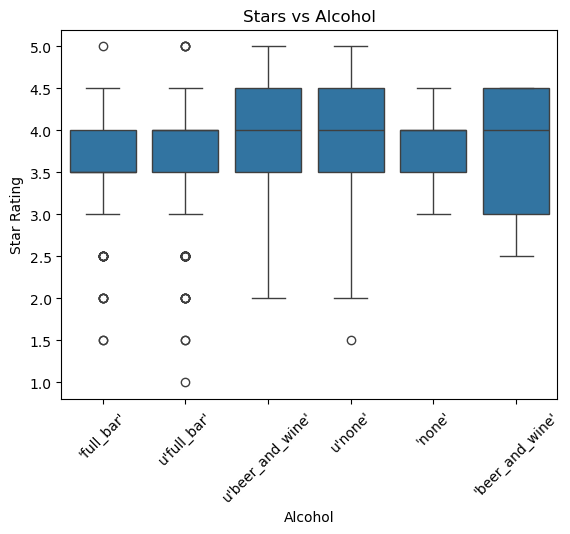

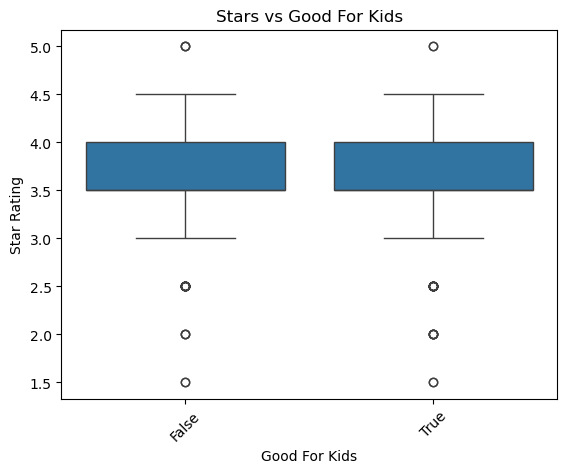

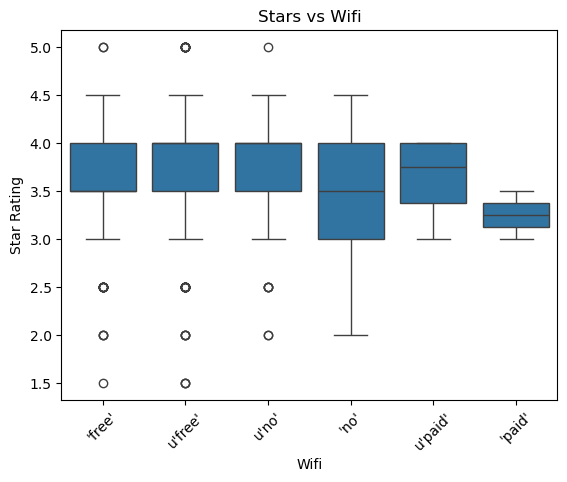

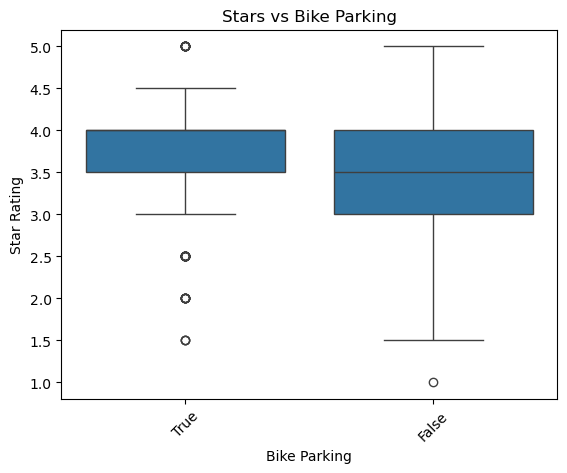

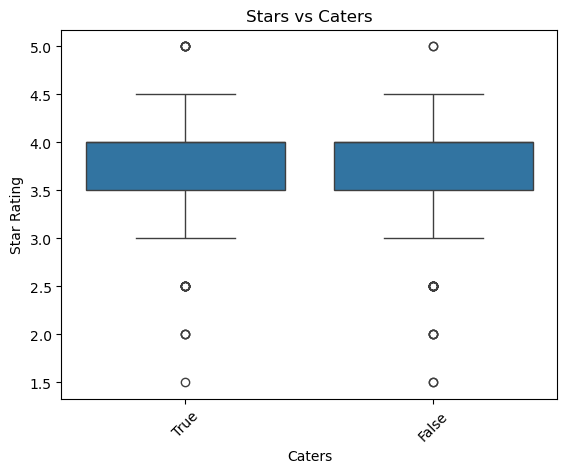

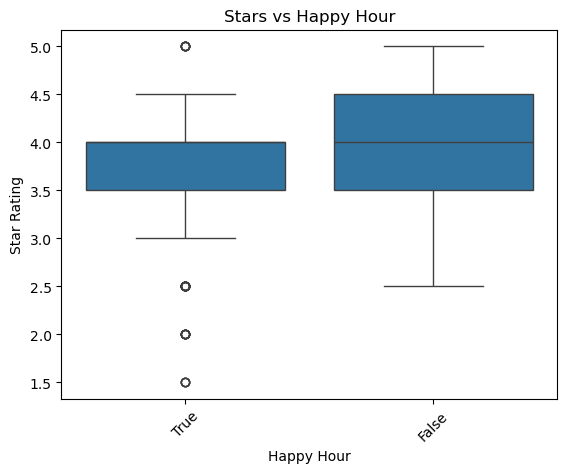

In [101]:
features = ['accepts_cards', 'take_out', 'delivery', 'outdoor_seating', 'reservations', 'has_tv', 
            'good_for_groups', 'alcohol', 'good_for_kids', 'wifi', 'bike_parking', 'caters','happy_hour']

for feature in features:
    filtered_df = final_df[
        (final_df[feature].notnull()) &
        (final_df[feature] != 'None') &
        (final_df[feature] != '')
    ]
    
    sns.boxplot(data=filtered_df, x=feature, y='stars')
    plt.title(f'Stars vs {feature.replace("_", " ").title()}')
    plt.xticks(rotation=45)
    plt.xlabel(feature.replace("_", " ").title())
    plt.ylabel('Star Rating')
    plt.show()

Only happy hour and alcohol service appear to raise median ratings, with bars offering these features posting around 4.0 to 4.2 stars compared to about 3.8 to 4.0 for those that do not. Other attributes such as catering, bike parking, wi fi, being good for groups, or having tv show almost identical medians and variability and therefore do not by themselves affect Yelp star ratings.










In [102]:
final_df[final_df['categories'].str.contains('Bars', case=False, na=False)].shape[0]

1015

# 9. Exploratory Data Analysis on Demographics

In [239]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.style

Checked for nulls in final_demographics_df and data types

In [240]:
final_demographics_df.isnull().sum()

GEOID                0
employment status    0
occupation           0
industry             0
worker_class         0
income_benefits      0
Males                0
Females              0
Above21              0
Above65              0
dtype: int64

In [242]:
final_demographics_df.dtypes

GEOID                object
employment status    object
occupation           object
industry             object
worker_class         object
income_benefits      object
Males                object
Females              object
Above21              object
Above65              object
dtype: object

In [243]:
final_demographics_df

,GEOID,employment status,occupation,industry,worker_class,income_benefits,Males,Females,Above21,Above65
0,42045403701,1502,817,817,817,742,958,773,1419,284
1,42045980000,0,0,0,0,0,0,0,0,0
2,42091202500,5151,3354,3354,3354,2510,2546,3280,4257,1080
3,42101000101,1980,1701,1701,1701,1492,690,1306,1980,229
4,42101000102,2816,2411,2411,2411,2033,1764,1261,2816,239
...,...,...,...,...,...,...,...,...,...,...
209,42101980600,0,0,0,0,0,0,0,0,0
210,42101980701,0,0,0,0,0,0,0,0,0
211,42101980702,0,0,0,0,0,0,0,0,0
212,42101980901,0,0,0,0,0,0,0,0,0


Removed any tracts where all numeric demographic fields were zero

In [248]:
cols_to_check = final_demographics_df.columns.difference(['GEOID'])
all_zeros = (final_demographics_df[cols_to_check].astype(float) == 0).all(axis=1)
print("Rows where all values are 0:", all_zeros.sum())

Rows where all values are 0: 10


In [249]:
final_demographics_df = final_demographics_df[(final_demographics_df[cols_to_check].astype(float) != 0).any(axis=1)]

In [250]:
final_demographics_df

,GEOID,employment status,occupation,industry,worker_class,income_benefits,Males,Females,Above21,Above65
0,42045403701,1502,817,817,817,742,958,773,1419,284
2,42091202500,5151,3354,3354,3354,2510,2546,3280,4257,1080
3,42101000101,1980,1701,1701,1701,1492,690,1306,1980,229
4,42101000102,2816,2411,2411,2411,2033,1764,1261,2816,239
5,42101000200,2977,1754,1754,1754,1742,1815,1444,2838,624
...,...,...,...,...,...,...,...,...,...,...
200,42101038400,2150,1325,1325,1325,1012,1132,1376,2010,563
201,42101038500,1703,954,954,954,924,852,1036,1607,638
202,42101038700,2230,1145,1145,1145,850,1133,1311,1844,826
203,42101038800,3292,2337,2337,2337,1869,2074,1917,3244,704


There are some rows with 0 values in the demographics data. We should drop those values when doing additional analysis as they will not provide insight into the geoid's. 

#### 9.2 Bar Chart of Sex

/var/folders/2y/ypwr61vn22s2vwgt1bpv7mvr0000gn/T/ipykernel_26255/1927651722.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_demographics_df['Males'] = final_demographics_df['Males'].astype(int)
/var/folders/2y/ypwr61vn22s2vwgt1bpv7mvr0000gn/T/ipykernel_26255/1927651722.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_demographics_df['Females'] = final_demographics_df['Females'].astype(int)


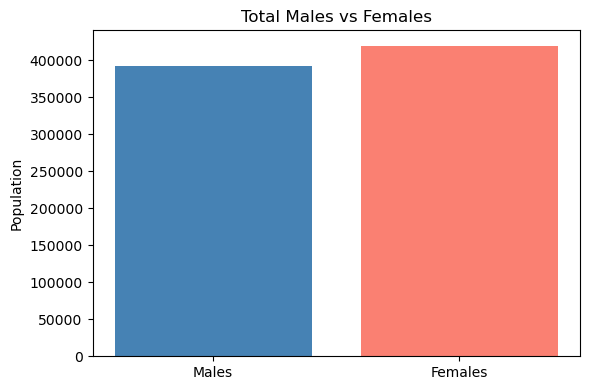

In [208]:
#convert to str type
final_demographics_df['Males'] = final_demographics_df['Males'].astype(int)
final_demographics_df['Females'] = final_demographics_df['Females'].astype(int)

# Sum totals
gender_totals = final_demographics_df[['Males', 'Females']].sum()

# Plot
plt.figure(figsize=(6, 4))
plt.bar(gender_totals.index, gender_totals.values, color=['steelblue', 'salmon'])
plt.title('Total Males vs Females')
plt.ylabel('Population')
plt.tight_layout()
plt.show()

While there are slightly more women, there is a good distribution of Males & Females in the dataset. 

#### 9.3 Bar Chart of Age Brackets

/var/folders/2y/ypwr61vn22s2vwgt1bpv7mvr0000gn/T/ipykernel_26255/962172584.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_demographics_df['Above21'] = final_demographics_df['Above21'].astype(int)
/var/folders/2y/ypwr61vn22s2vwgt1bpv7mvr0000gn/T/ipykernel_26255/962172584.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_demographics_df['Above65'] = final_demographics_df['Above65'].astype(int)


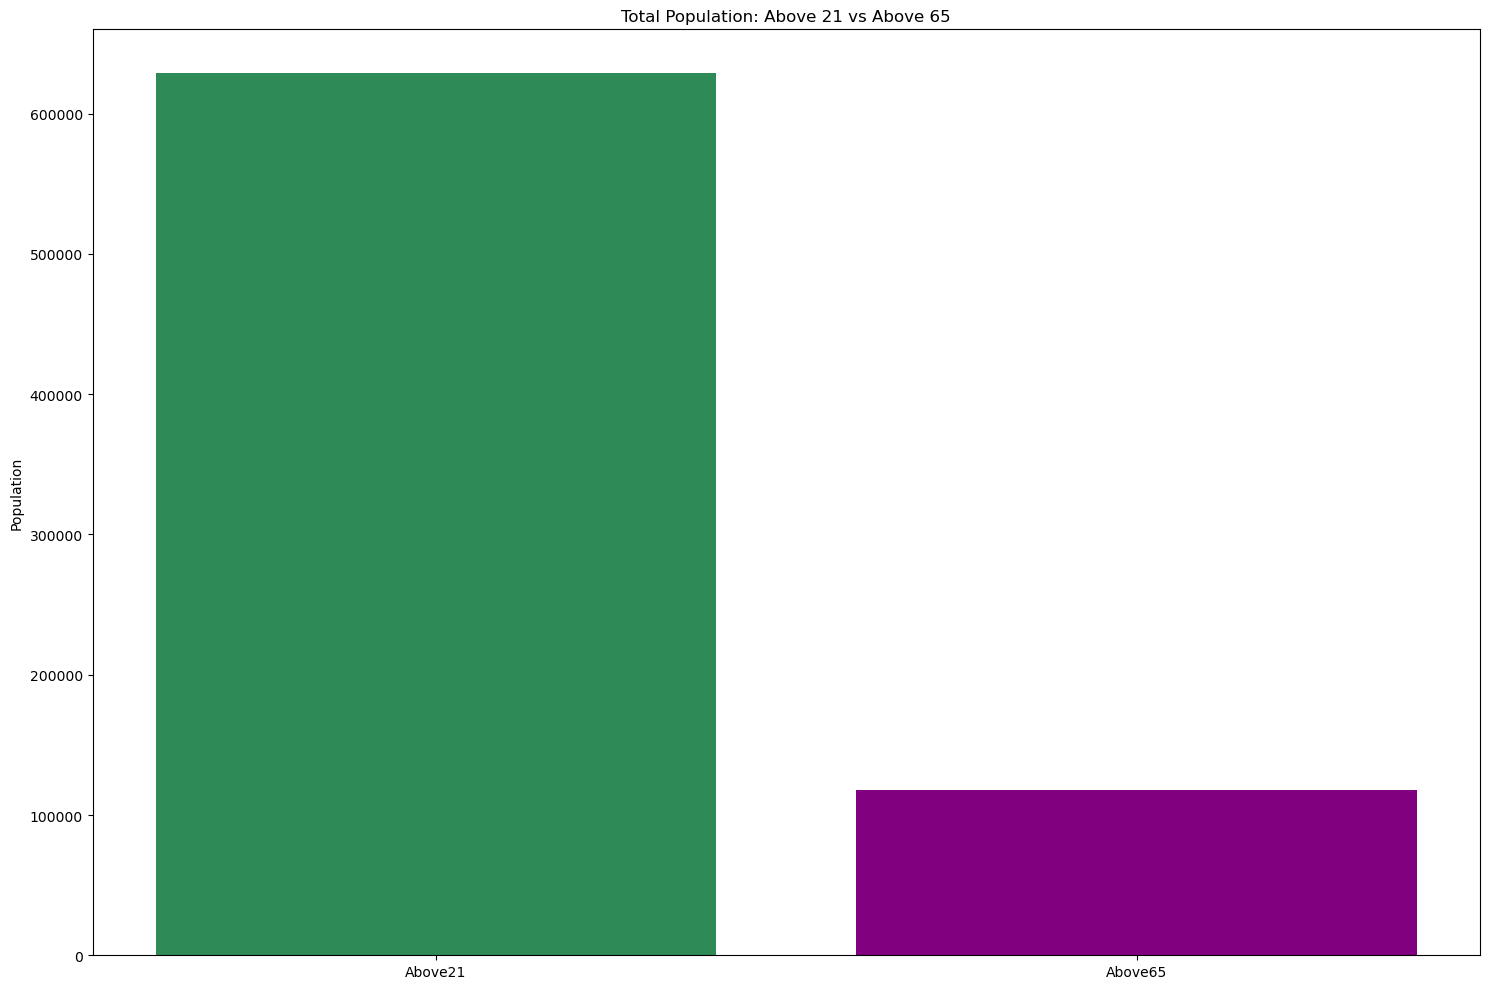

In [212]:
# Convert to int types
final_demographics_df['Above21'] = final_demographics_df['Above21'].astype(int)
final_demographics_df['Above65'] = final_demographics_df['Above65'].astype(int)

# Sum totals                                                                         
age_totals = final_demographics_df[['Above21', 'Above65']].sum()

# Plot
plt.figure(figsize=(15, 10))
plt.bar(age_totals.index, age_totals.values, color=['seagreen', 'purple'])
plt.title('Total Population: Above 21 vs Above 65')
plt.ylabel('Population')
plt.tight_layout()
plt.show()

There is a large population of people Above 21 as compared to Above 65. While this might impact modeling, since we have chosen to work towards identifying hotspots for Bars, the target population has a good population. 

#### Box Plot of Income (with Benefits)

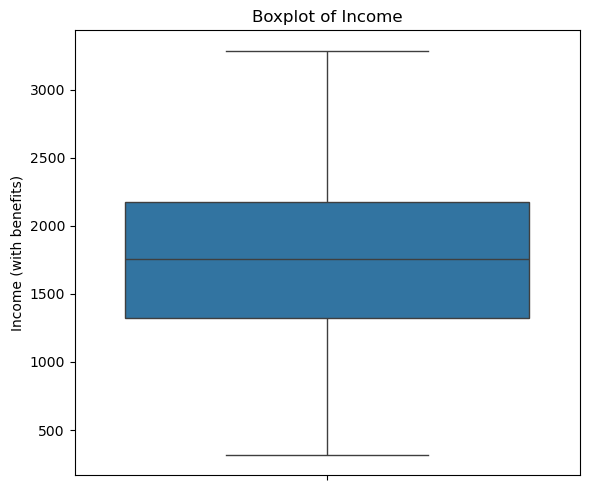

In [268]:
plt.figure(figsize=(6, 5))
sns.boxplot(y= final_demographics_df['income_benefits'])
plt.title('Boxplot of Income')
plt.ylabel('Income (with benefits)')
plt.tight_layout()
plt.show()

The average income in counties is approximately $1800. There is a good range & there are some 0's in the income that might need to be removed.

#### 9.5 Box Plot of Employment Status

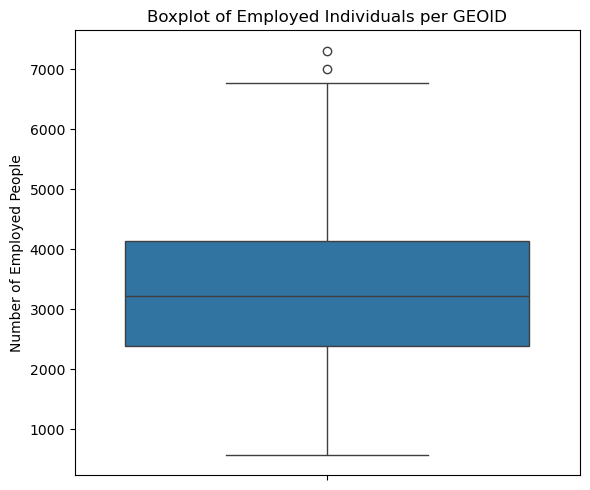

In [270]:
plt.figure(figsize=(6, 5))
sns.boxplot(y=final_demographics_df['employment status'])
plt.title('Boxplot of Employed Individuals per GEOID')
plt.ylabel('Number of Employed People')
plt.tight_layout()
plt.show()

On average there are 3000 employed people in each county with some outliers. There is a good range & there are some 0's in the number of employed people that might need to be removed.